# BinML quickstart: simulate, classify, watch a season unfold

Runs offline in under a minute. It simulates one event of each of BinML's six classes with the
released generator, classifies the full 72-day season with the shipped weights, and then reveals
a planetary binary half a day at a time to show when the anomaly probability crosses the
operating threshold.

What to keep in mind: the label attached to a simulated event is **observational**, decided by a
detectability policy (Δχ² thresholds and a 0.02 mag floor on the noise-free curve), not by which
generator produced it. A binary lens whose anomaly is undetectable is labelled `PSPL`; an event
with nothing detectable is `Flat`. See `docs/pipeline.md` and the paper's Section 2.

In [1]:
import json, warnings, numpy as np, matplotlib.pyplot as plt
warnings.simplefilter("ignore")
import binml
from pipeline.assemble import SurveyConfig, simulate_event

clf = binml.Classifier()            # shipped weights, 6 classes
cfg = SurveyConfig()
threshold = json.load(open("../paper/results/metrics.json"))["headline"]["threshold"]
print(binml.__version__, clf.class_names, f"operating threshold {threshold:.4f}")

1.0.0 ['Flat', 'PSPL', 'NonPSPL', 'PeriodicVar', 'LongPeriodVar', 'Eruptive'] operating threshold 0.9042


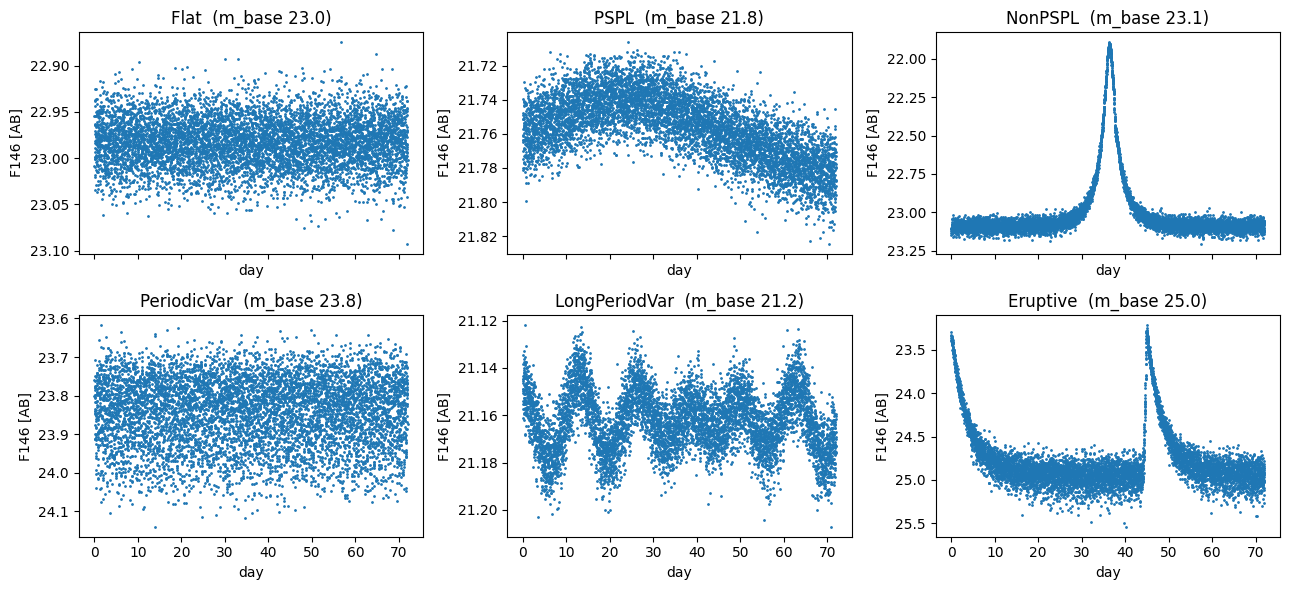

In [2]:
# one event per generator class; the observational label may differ from the generator class
events = {}
for k, cls in enumerate(["Flat", "PSPL", "NonPSPL", "PeriodicVar", "LongPeriodVar", "Eruptive"]):
    rng = np.random.default_rng(100 + k)
    ev = None
    while ev is None or ev.label != cls:           # draw until the observational label matches
        ev = simulate_event(cls, rng, cfg)
    events[cls] = ev
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, (cls, ev) in zip(axes.ravel(), events.items()):
    b = ev.bands["F146"]
    ax.plot(b.t, b.mag, ".", ms=2); ax.invert_yaxis(); ax.set_title(f"{cls}  (m_base {ev.params['_m_base_ref']:.1f})")
    ax.set_xlabel("day"); ax.set_ylabel("F146 [AB]")
plt.tight_layout()

In [3]:
# classify each full season: the model takes {band: (t_days, mag)} and the F146 baseline
for cls, ev in events.items():
    bands = {name: (b.t, b.mag) for name, b in ev.bands.items() if b.t.size}
    p = clf.predict(bands, m_base_ref=ev.params["_m_base_ref"], t_start=0.0)
    top = sorted(p.probabilities.items(), key=lambda kv: -kv[1])[:2]
    print(f"{cls:14s} -> {p.label:14s}  " + "  ".join(f"{k} {v:.2f}" for k, v in top))

Flat           -> Flat            Flat 1.00  PeriodicVar 0.00
PSPL           -> PSPL            PSPL 0.94  NonPSPL 0.06
NonPSPL        -> NonPSPL         NonPSPL 0.84  PSPL 0.15


PeriodicVar    -> PeriodicVar     PeriodicVar 1.00  Eruptive 0.00
LongPeriodVar  -> LongPeriodVar   LongPeriodVar 1.00  Flat 0.00
Eruptive       -> Eruptive        Eruptive 1.00  NonPSPL 0.00


## A season revealed half a day at a time

`predict_evolution` scores the same event on growing prefixes of the season. For a planetary binary
(seed 241, mass ratio 3.8e-4) the `NonPSPL` probability stays low while only the smooth single-lens
rise is visible and crosses the operating threshold a few days after the anomaly becomes detectable.
`t_anom` is the generator's truth-informed first-detectable onset; it is recorded on a 7.2-day grid
by default (the released training data), and on the half-day grid used by the paper's cascade
evaluation when `SurveyConfig(onset_resolution_days=0.5)` is set, as here. The paper's
premature-alert rate counts crossings before that onset.

first crossing at day 49.5 | onset 43.5


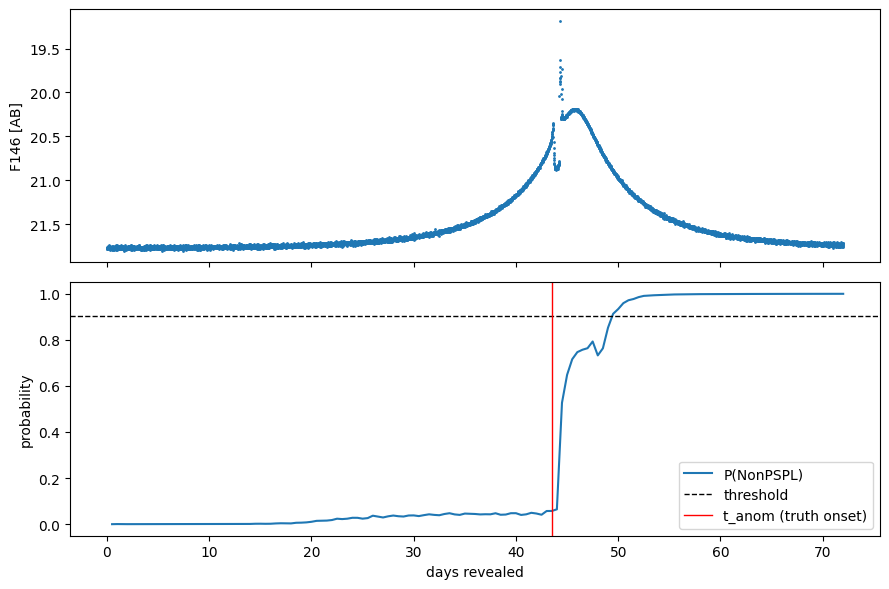

In [4]:
import dataclasses
cfg_fine = dataclasses.replace(cfg, onset_resolution_days=0.5)
ev = simulate_event("NonPSPL", np.random.default_rng(241), cfg_fine)     # a planetary binary
bands = {name: (b.t, b.mag) for name, b in ev.bands.items() if b.t.size}
days, probs = clf.predict_evolution(bands, m_base_ref=ev.params["_m_base_ref"], t_start=0.0, n_steps=144)
i_non = clf.class_names.index("NonPSPL")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
b = ev.bands["F146"]; a1.plot(b.t, b.mag, ".", ms=2); a1.invert_yaxis(); a1.set_ylabel("F146 [AB]")
a2.plot(days, probs[:, i_non], label="P(NonPSPL)"); a2.axhline(threshold, ls="--", c="k", lw=1, label="threshold")
if np.isfinite(ev.params.get("t_anom", np.inf)):
    a2.axvline(ev.params["t_anom"], c="r", lw=1, label="t_anom (truth onset)")
a2.set_xlabel("days revealed"); a2.set_ylabel("probability"); a2.legend(); plt.tight_layout()
cross = days[np.flatnonzero(probs[:, i_non] >= threshold)]
print("first crossing at day", cross[0] if cross.size else None, "| onset", ev.params.get("t_anom"))

## Where to go next

* `01_classify_roman_event.ipynb`: the same classifier on an event from an independent Roman
  simulation (RMDC26/GULLS), with the season and baseline handled by `binml.gulls`.
* `docs/usage.md` for the CLI and batch interfaces; `docs/model_card.md` for the input contract
  and known weak spots; `paper/REVISION.md` for everything learned after submission.